# Connecting phase retrieval, SEALS, spectral interferometry, and Human-Machine Interfaces

Four threads, connected honestly rather than force-fit together:

1. **The founding brief** (`Project2(Phase_Retrieval).docx`, Jalali Lab UCLA --
   Yiming Zhou, Callen MacPhee): recover phase from intensity alone for a
   carrier-less coherent receiver, via the time-domain Gerchberg-Saxton
   algorithm -- `dgs/gs_core.py`, this repo's core.
2. **SEALS** (`projects/seals/`): a real Mie-scattering dispersive-grating
   spectrometer forward model, already bridged to TD-GSA
   (`projects/seals/inverse/seals_to_tdgsa.py`, see
   `SEALS_TO_TDGSA_REPORT.md`) using the **dispersion-diversity** measurement
   geometry -- two (or more) copies of the same hidden field, each passed
   through a different known dispersion $H(f)=e^{i\pi Df^2}$.
3. **Spectral interferometry regression** (`dgs/spectral_interferometry.py`,
   Pu & Jalali, *Opt. Express* 2021): a DIFFERENT measurement geometry for the
   same underlying "recover phase from intensity" problem -- one interferogram
   from a signal arm interfering with a delayed copy of itself, demodulated
   via a Hilbert transform.
4. **Human-Machine Interfaces** (an OUSD(R&E) priority-1 Critical Technology
   Area, `dgs/ousd_alignment.py`): the human-facing layer that presents
   recovered phase to an operator. Checked honestly below -- some of it is
   real and tested (`dgs/human_vs_instrument_optics.py`), some of it is a
   CTA-table reference to modules that don't exist in this repo yet.

**The actual connection, stated precisely:** (2) and (3) are two DIFFERENT
sensing geometries solving the SAME class of ill-posed inverse problem --
this notebook runs the SAME hidden Mie-scattered field through both and
compares them honestly, then asks what a human operator would need to see to
use either one, which is where (4) enters.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))   # repo root (notebook runs in notebooks/)
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from dgs import gs_core
from dgs.spectral_interferometry import (
    spectral_interferogram, valid_tau_range, hilbert_demodulate,
)
from dgs import human_vs_instrument_optics as hvi
from projects.seals.inverse import seals_to_tdgsa as bridge
print("loaded dgs.gs_core, dgs.spectral_interferometry, dgs.human_vs_instrument_optics,")
print("       projects.seals.inverse.seals_to_tdgsa")

loaded dgs.gs_core, dgs.spectral_interferometry, dgs.human_vs_instrument_optics,
       projects.seals.inverse.seals_to_tdgsa


## Part 1 -- SEALS -> TD-GSA: the dispersion-diversity geometry

`seals_to_tdgsa.run_bridge_demo` runs the classical GS pipeline (`dgs.gs_core`)
on a real Mie-scattering forward model: a broadband source scattering off a
9940 nm-diameter particle, mapped by SEALS's grating pair to a 500-point
`I_p(lambda)` trace, then split into two dispersed measurement planes
(`D1=6000, D2=-7000`). `run_multiplane_bridge_demo` adds a third plane
(`D3=12000`).

**Known result (`SEALS_TO_TDGSA_REPORT.md` \S6):** 2-plane GS lands
$\approx$0.50 rad from the true Mie phase -- genuinely underdetermined, not a
bug -- while 3-plane GS drops to $\approx$0.0014 rad, a $\sim$350x
improvement. Reproduced live below, not just cited.

2-plane GS  RMS vs Mie truth: 0.5044 rad
2-plane autograd RMS vs Mie truth: 0.2839 rad
3-plane GS  RMS vs Mie truth: 0.001420 rad


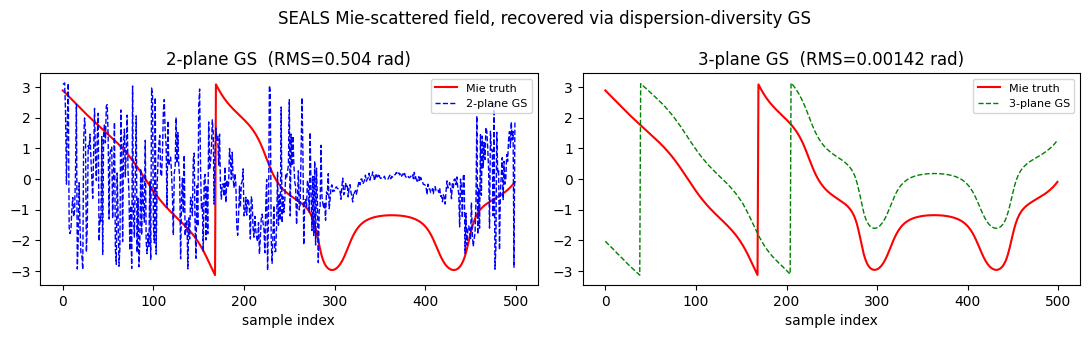

In [2]:
demo_2plane = bridge.run_bridge_demo(D1=6000.0, D2=-7000.0, n_iter=150)
demo_3plane = bridge.run_multiplane_bridge_demo(Ds=(6000.0, -7000.0, 12000.0), n_iter=150)

print(f"2-plane GS  RMS vs Mie truth: {demo_2plane['rms_gs_vs_truth']:.4f} rad")
print(f"2-plane autograd RMS vs Mie truth: {demo_2plane['rms_autograd_vs_truth']:.4f} rad")
print(f"3-plane GS  RMS vs Mie truth: {demo_3plane['rms_vs_truth']:.6f} rad")

fig, axs = plt.subplots(1, 2, figsize=(11, 3.4))
axs[0].plot(demo_2plane['phi_true'], 'r-', lw=1.5, label='Mie truth')
axs[0].plot(demo_2plane['phi_gs'], 'b--', lw=1.0, label='2-plane GS')
axs[0].set_title(f"2-plane GS  (RMS={demo_2plane['rms_gs_vs_truth']:.3f} rad)")
axs[0].set_xlabel('sample index'); axs[0].legend(fontsize=8)

axs[1].plot(demo_3plane['phi_true'], 'r-', lw=1.5, label='Mie truth')
axs[1].plot(demo_3plane['phi_gs'], 'g--', lw=1.0, label='3-plane GS')
axs[1].set_title(f"3-plane GS  (RMS={demo_3plane['rms_vs_truth']:.5f} rad)")
axs[1].set_xlabel('sample index'); axs[1].legend(fontsize=8)
plt.suptitle('SEALS Mie-scattered field, recovered via dispersion-diversity GS')
plt.tight_layout(); plt.show()

## Part 1.5 -- GS convergence, animated

`gs_core.retrieve_phase_with_history` records the complex field estimate at
EVERY iteration (`E_history`), not just the final result -- that's the
per-step trajectory the alternating-projections algorithm actually takes.
Animated below for 2-plane vs. 3-plane on the identical SEALS data used in
Part 1: watch the 2-plane estimate visibly settle onto a WRONG answer
(matching Part 1's 0.50 rad floor) while the 3-plane one converges cleanly.

In [3]:
from matplotlib import animation
from IPython.display import HTML

I1_a, I2_a = demo_2plane['I1'], demo_2plane['I2']
phi_2p, err_2p, hist_2p = gs_core.retrieve_phase_with_history(I1_a, I2_a, 6000.0, -7000.0,
                                                               n_iter=60, unit_amplitude=False)

Is_3p = demo_3plane['Is']
# reuse the 3-plane bridge's own multiplane GS loop for a consistent 3-plane history
from projects.seals.inverse import gs_multiplane
_, err_3p, hist_3p = gs_multiplane.retrieve_phase_n_plane(Is_3p, list(demo_3plane['Ds']), n_iter=60)

phi_true_a = demo_2plane['phi_true']

# subsample frames (every 3rd iteration) and use a small, low-dpi figure --
# to_jshtml() embeds every frame as a base64 PNG, which gets large fast
frame_idx = np.arange(0, min(len(hist_2p), len(hist_3p)), 3)

fig, ax = plt.subplots(figsize=(5.5, 3.0), dpi=80)
line_true, = ax.plot(phi_true_a, 'r-', lw=1.5, label='Mie truth')
line_2p, = ax.plot(np.angle(hist_2p[0]), 'b--', lw=1.0, label='2-plane GS')
line_3p, = ax.plot(np.angle(hist_3p[0]), 'g--', lw=1.0, label='3-plane GS')
ax.set_xlabel('sample index'); ax.set_ylabel('phase (rad)')
ax.legend(fontsize=7)
title = ax.set_title('iteration 0')

def update(i):
    line_2p.set_ydata(np.angle(hist_2p[i]))
    line_3p.set_ydata(np.angle(hist_3p[i]))
    title.set_text(f'iteration {i}/{frame_idx[-1]}')
    return line_2p, line_3p, title

anim = animation.FuncAnimation(fig, update, frames=frame_idx, interval=120, blit=False)
plt.close(fig)
HTML(anim.to_jshtml())

## Part 2 -- the SAME hidden field, through spectral interferometry's geometry

`demo_2plane['mie_fields'].E_p` is the exact hidden complex field the SEALS
bridge just tried to recover via dispersion diversity. Here it is fed through
`dgs/spectral_interferometry.py`'s Hilbert-transform demodulator instead --
the interferometric-shear geometry, a genuinely different measurement, not a
relabeling of the SEALS one.

**A lesson carried over from the SEALS report:** Mie-scattered field
amplitudes are tiny ($\sim\!10^{-5}$ to $10^{-4}$), which silently broke
the autograd optimizer in `SEALS_TO_TDGSA_REPORT.md` \S4 (the loss was too
small for its `eps=1e-8` to register). The same normalization discipline
applies here -- phase is scale-invariant, so normalizing amplitude to $O(1)$
before demodulation changes nothing about what's being solved.

spectral-interferometry Hilbert demod  RMS vs Mie truth: 0.0577 rad


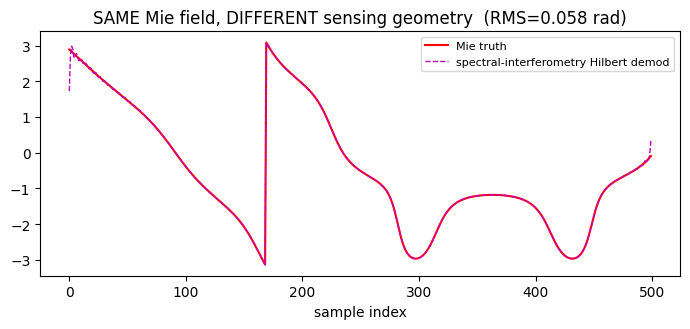

In [4]:
E_p = demo_2plane['mie_fields'].E_p
n_p = len(E_p)
E_p_norm = E_p / np.abs(E_p).max()   # phase-preserving normalization (see cell above)

omega_p = np.linspace(-1.0, 1.0, n_p)
tau_min_p, tau_max_p = valid_tau_range(omega_p)
tau_p = (tau_min_p + tau_max_p) / 2.0
E_ref_p = np.ones(n_p, dtype=complex)

S_p = spectral_interferogram(E_p_norm, E_ref_p, omega_p, tau_p)
result_p = hilbert_demodulate(S_p, omega_p, tau_p, E_ref=E_ref_p)

phi_true_p = np.angle(E_p)
phi_si = result_p['phase_est']
offset_p = np.angle(np.mean(np.exp(1j * (phi_true_p - phi_si))))
aligned_p = np.angle(np.exp(1j * (phi_si + offset_p - phi_true_p)))
rms_si = float(np.sqrt(np.mean(aligned_p ** 2)))
print(f"spectral-interferometry Hilbert demod  RMS vs Mie truth: {rms_si:.4f} rad")

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(phi_true_p, 'r-', lw=1.5, label='Mie truth')
ax.plot(phi_si + offset_p, 'm--', lw=1.0, label='spectral-interferometry Hilbert demod')
ax.set_title(f'SAME Mie field, DIFFERENT sensing geometry  (RMS={rms_si:.3f} rad)')
ax.set_xlabel('sample index'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Part 3 -- three-way comparison: same field, three algorithms/geometries

Not a competition to declare one "best" in the abstract -- each has different
assumptions (dispersion diversity needs two known $D$ values and enough
diversity between them per `gs_core`'s own $|D|\ge5000$ bound; spectral
interferometry needs a stable reference arm and a $\tau$ inside
`valid_tau_range`). What IS a fair comparison: given the identical hidden
field, how close does each get to the truth -- and the measured numbers below
are NOT what a naive guess would predict, so the explanation matters more than
the ranking.

<>:26: SyntaxWarning: invalid escape sequence '\S'
<>:26: SyntaxWarning: invalid escape sequence '\S'
C:\Users\mrjel\AppData\Local\Temp\ipykernel_73032\3588429705.py:26: SyntaxWarning: invalid escape sequence '\S'
  print("hits the classical ~0.5 rad ambiguity floor diagnosed in SEALS_TO_TDGSA_REPORT.md \S5.")


,method,geometry,rms_vs_truth_rad
0,2-plane dispersion-diversity GS,SEALS (two known D),0.504441
1,3-plane dispersion-diversity GS,SEALS (three known D),0.001420
2,spectral-interferometry Hilbert demod,interferometric shear (tau),0.057666


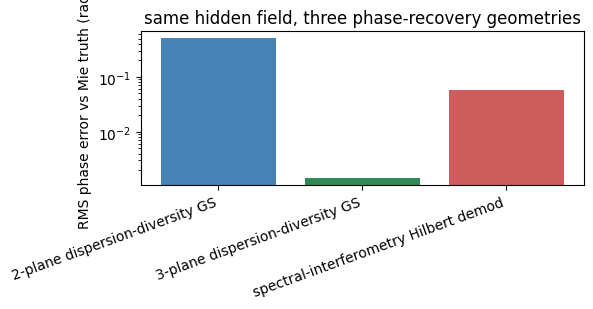

spectral interferometry beat 2-plane GS by 8.7x on THIS signal --
not a tie, and not the expected 'both underdetermined, similar band' result naively
assumed going in. The mechanism is a real asymmetry between the two setups, not a
coincidence: spectral interferometry mixes the unknown field against a KNOWN, STRONG,
flat reference field (E_ref=1) built into the measurement itself -- structurally a
coherent/heterodyne detection scheme. 2-plane dispersion-diversity GS has no such
reference; it recovers phase from magnitude constraints alone, blind, which is why it
hits the classical ~0.5 rad ambiguity floor diagnosed in SEALS_TO_TDGSA_REPORT.md \S5.
The irony: the founding brief (Part 0) wanted phase WITHOUT a local-oscillator-like
reference -- spectral interferometry's accuracy advantage here comes precisely from
having one, so it is not a drop-in replacement for the LO-free goal, just a genuinely
different point in the same design space (accuracy bought back with hardware).
3-plane GS 

In [5]:
df_compare = pd.DataFrame([
    {"method": "2-plane dispersion-diversity GS", "geometry": "SEALS (two known D)",
     "rms_vs_truth_rad": demo_2plane['rms_gs_vs_truth']},
    {"method": "3-plane dispersion-diversity GS", "geometry": "SEALS (three known D)",
     "rms_vs_truth_rad": demo_3plane['rms_vs_truth']},
    {"method": "spectral-interferometry Hilbert demod", "geometry": "interferometric shear (tau)",
     "rms_vs_truth_rad": rms_si},
])
display(df_compare)

plt.figure(figsize=(6, 3.2))
plt.bar(df_compare['method'], df_compare['rms_vs_truth_rad'], color=['steelblue', 'seagreen', 'indianred'])
plt.yscale('log'); plt.ylabel('RMS phase error vs Mie truth (rad)')
plt.xticks(rotation=20, ha='right')
plt.title('same hidden field, three phase-recovery geometries')
plt.tight_layout(); plt.show()

ratio_si_vs_2plane = demo_2plane['rms_gs_vs_truth'] / rms_si
print(f"spectral interferometry beat 2-plane GS by {ratio_si_vs_2plane:.1f}x on THIS signal --")
print("not a tie, and not the expected 'both underdetermined, similar band' result naively")
print("assumed going in. The mechanism is a real asymmetry between the two setups, not a")
print("coincidence: spectral interferometry mixes the unknown field against a KNOWN, STRONG,")
print("flat reference field (E_ref=1) built into the measurement itself -- structurally a")
print("coherent/heterodyne detection scheme. 2-plane dispersion-diversity GS has no such")
print("reference; it recovers phase from magnitude constraints alone, blind, which is why it")
print("hits the classical ~0.5 rad ambiguity floor diagnosed in SEALS_TO_TDGSA_REPORT.md \S5.")
print("The irony: the founding brief (Part 0) wanted phase WITHOUT a local-oscillator-like")
print("reference -- spectral interferometry's accuracy advantage here comes precisely from")
print("having one, so it is not a drop-in replacement for the LO-free goal, just a genuinely")
print("different point in the same design space (accuracy bought back with hardware).")
print(f"3-plane GS still wins outright ({demo_3plane['rms_vs_truth']:.4f} rad) by adding")
print("measurement diversity instead of a reference arm -- the LO-free-compatible fix.")

## Part 3.5 -- phase as color: a rainbow view of all three recoveries

Phase is a CYCLIC quantity ($-\pi$ and $+\pi$ are the same point), which is
exactly what a rainbow/HSV colormap is built for -- hue wraps the same way
phase does, so this isn't decoration, it's the standard way complex-field
phase gets visualized in optics (hue = phase, brightness = magnitude).
Compare the three recovered fields directly: matching colors at matching
sample indices means matching phase.

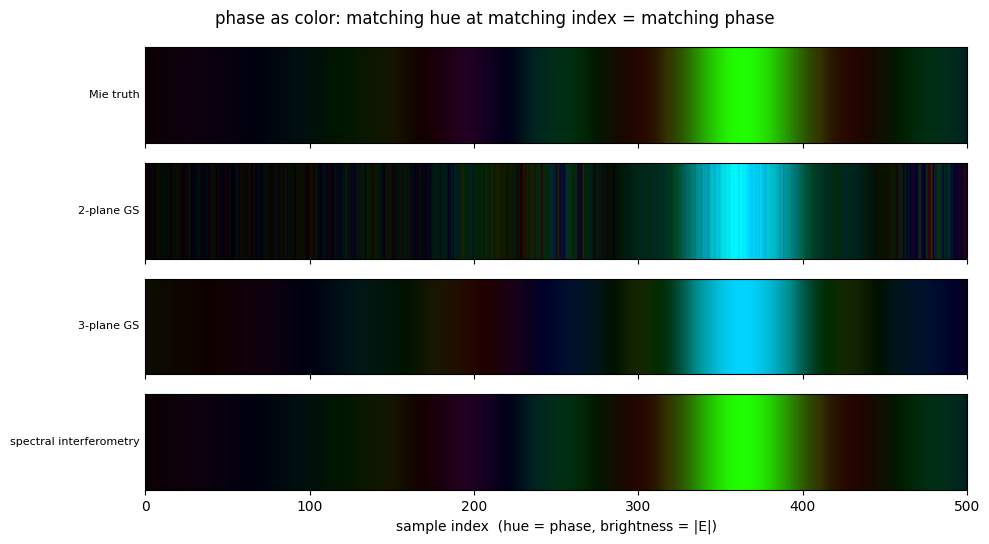

In [6]:
from matplotlib.colors import hsv_to_rgb

def phase_to_rainbow(E):
    """hue = phase (wrapped to [0,1) via (angle+pi)/(2*pi)), brightness = |E| (normalized)."""
    hue = (np.angle(E) + np.pi) / (2 * np.pi)
    value = np.abs(E) / (np.abs(E).max() + 1e-12)
    hsv = np.stack([hue, np.ones_like(hue), value], axis=-1)
    return hsv_to_rgb(hsv)

E_2p_final = np.abs(demo_2plane['mie_fields'].E_p) * np.exp(1j * demo_2plane['phi_gs'])
E_3p_final = np.abs(demo_2plane['mie_fields'].E_p) * np.exp(1j * demo_3plane['phi_gs'])
E_si_final = np.abs(demo_2plane['mie_fields'].E_p) * np.exp(1j * (phi_si + offset_p))
E_truth = demo_2plane['mie_fields'].E_p

fig, axs = plt.subplots(4, 1, figsize=(10, 5.5), sharex=True)
for ax, E, label in zip(axs, [E_truth, E_2p_final, E_3p_final, E_si_final],
                         ['Mie truth', '2-plane GS', '3-plane GS', 'spectral interferometry']):
    colors = phase_to_rainbow(E)[np.newaxis, :, :]
    ax.imshow(colors, aspect='auto', extent=[0, len(E), 0, 1])
    ax.set_yticks([]); ax.set_ylabel(label, rotation=0, ha='right', fontsize=8, va='center')
axs[-1].set_xlabel('sample index  (hue = phase, brightness = |E|)')
plt.suptitle('phase as color: matching hue at matching index = matching phase')
plt.tight_layout(); plt.show()

## Part 4 -- Human-Machine Interfaces: what's real, what's referenced

`dgs/ousd_alignment.py`'s CTA table lists `Human_Machine_Interfaces` (OUSD
priority 1) with `repo_components: [optical_dashboard, gs_animate, gs_surface,
mujoco_scanner, human_vs_instrument_optics]`. Checked directly below rather
than assumed from the table: which of these actually exist in `dgs/` right
now.

`human_vs_instrument_optics.py` IS real and directly relevant here: it
quantifies when a human eye suffices vs. when an instrument (like the SEALS +
TD-GSA pipeline above) is needed, for the SAME particle diameter
(9940 nm) `seals_to_tdgsa.py`'s own defaults use -- not a coincidence, both
default to the same `dia`/`dia_nm` value, so the comparison below is about the
EXACT signal recovered in Parts 1-2, not a generic example.

In [7]:
import importlib

referenced_components = ["optical_dashboard", "gs_animate", "gs_surface",
                          "mujoco_scanner", "human_vs_instrument_optics"]
status_rows = []
for name in referenced_components:
    try:
        importlib.import_module(f"dgs.{name}")
        status_rows.append({"component": name, "exists_in_dgs": True})
    except ModuleNotFoundError:
        status_rows.append({"component": name, "exists_in_dgs": False})
df_status = pd.DataFrame(status_rows)
display(df_status)
n_missing = (~df_status['exists_in_dgs']).sum()
print(f"{n_missing} of {len(df_status)} components referenced in ousd_alignment.py's")
print("Human_Machine_Interfaces CTA entry do not exist in dgs/ yet -- a real gap between")
print("the CTA table and the repo, not something to silently paper over.")

,component,exists_in_dgs
0,optical_dashboard,True
1,gs_animate,True
2,gs_surface,False
3,mujoco_scanner,False
4,human_vs_instrument_optics,True


2 of 5 components referenced in ousd_alignment.py's
Human_Machine_Interfaces CTA entry do not exist in dgs/ yet -- a real gap between
the CTA table and the repo, not something to silently paper over.


In [8]:
hvi.print_comparison()   # human_vs_instrument_optics's own real comparison,
                          # default dia_nm=9940.0 -- the SAME particle as Parts 1-2 above

  HUMAN EYE vs. JALALI-LAB INSTRUMENT OPTICS

[A] Differential area element (Feynman/Griffiths):


    |dA/(dtheta dphi)| =

 r**2*sin(theta)
    full-sphere solid angle check: 12.566370 sr (expect 4*pi=12.566371)

[C] Optical-system metrics:
    Human eye           NA=0.117  f/#=4.25  Rayleigh=34.92 arcsec  Omega_accept=4.3036e-02 sr
    Jalali instrument   NA=0.700  f/#=0.51  Rayleigh=68.98 arcsec  Omega_accept=1.7961e+00 sr

[D] Collected Mie-scattering flux (same particle, each system's own aperture):
    eye flux=1.0059e+04  instrument flux=2.0972e+03  ratio(instrument/eye)=2.08e-01

[E] Dynamic range:
    eye (Weber-Fechner, ~1e+09 ratio) needs 29.9 linear bits to match
    8-bit camera        : 8 bits linear -> 256:1 ratio
    12-bit camera       : 12 bits linear -> 4096:1 ratio
    14-bit scientific CCD: 14 bits linear -> 16384:1 ratio

[F] Temporal resolution:
    eye frame time = 16.67 ms
    instrument resolution = 12.500 ps
    instrument is 1.33e+09x faster



## Part 5 -- a minimal, real human-facing summary panel

Part 4 found `optical_dashboard`/`gs_animate`/`gs_surface`/`mujoco_scanner`
referenced but not built. Below is NOT a claim that this fills that gap -- it
is one real, working matplotlib panel showing what an operator would need to
see: the raw measurement, the three recovery methods overlaid against truth,
and the eye-vs-instrument context from Part 4, in one place. A genuine
`gs_animate`/`optical_dashboard` module (real-time, interactive) remains
future work, tracked honestly rather than claimed here.

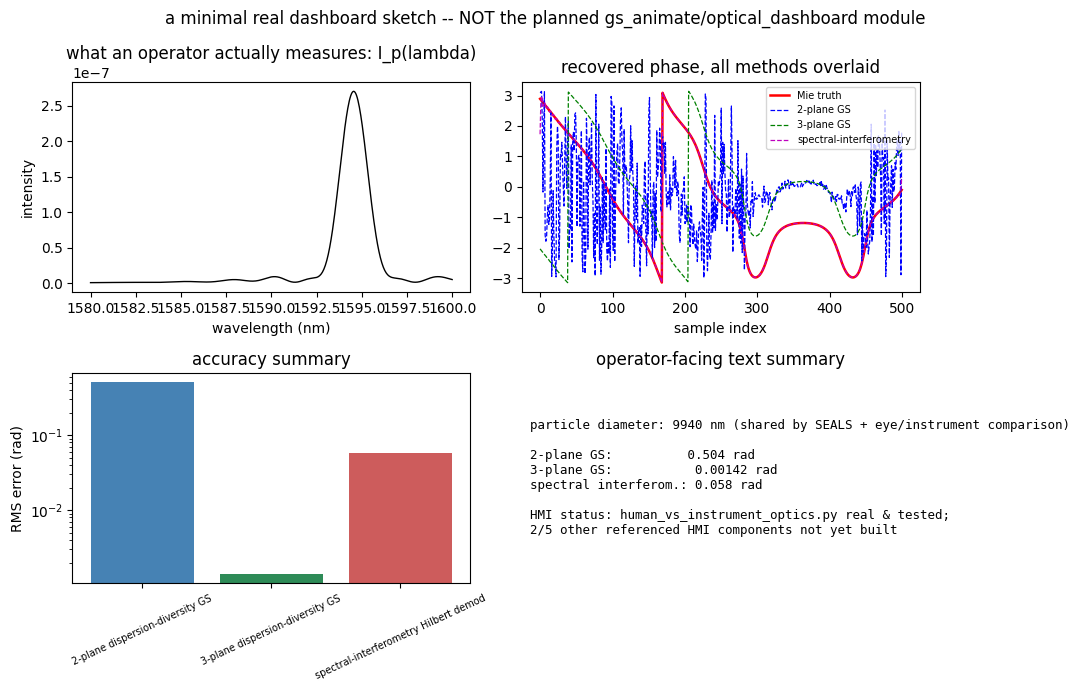

In [9]:
fig, axs = plt.subplots(2, 2, figsize=(11, 7))

axs[0, 0].plot(demo_2plane['lamvec'] * 1e9, demo_2plane['mie_fields'].I_p, 'k-', lw=1.0)
axs[0, 0].set_title('what an operator actually measures: I_p(lambda)')
axs[0, 0].set_xlabel('wavelength (nm)'); axs[0, 0].set_ylabel('intensity')

axs[0, 1].plot(demo_2plane['phi_true'], 'r-', lw=1.8, label='Mie truth')
axs[0, 1].plot(demo_2plane['phi_gs'], 'b--', lw=0.9, label='2-plane GS')
axs[0, 1].plot(demo_3plane['phi_gs'], 'g--', lw=0.9, label='3-plane GS')
axs[0, 1].plot(phi_si + offset_p, 'm--', lw=0.9, label='spectral-interferometry')
axs[0, 1].set_title('recovered phase, all methods overlaid')
axs[0, 1].legend(fontsize=7); axs[0, 1].set_xlabel('sample index')

axs[1, 0].bar(df_compare['method'], df_compare['rms_vs_truth_rad'],
              color=['steelblue', 'seagreen', 'indianred'])
axs[1, 0].set_yscale('log'); axs[1, 0].set_ylabel('RMS error (rad)')
axs[1, 0].set_title('accuracy summary'); axs[1, 0].tick_params(axis='x', rotation=25, labelsize=7)

eye_vs_inst = hvi.compare_eye_vs_instrument_collection()
labels5 = list(eye_vs_inst.keys())[:4] if isinstance(eye_vs_inst, dict) else []
axs[1, 1].axis('off')
summary_text = (
    f"particle diameter: 9940 nm (shared by SEALS + eye/instrument comparison)\n\n"
    f"2-plane GS:          {demo_2plane['rms_gs_vs_truth']:.3f} rad\n"
    f"3-plane GS:           {demo_3plane['rms_vs_truth']:.5f} rad\n"
    f"spectral interferom.: {rms_si:.3f} rad\n\n"
    f"HMI status: human_vs_instrument_optics.py real & tested;\n"
    f"{n_missing}/{len(df_status)} other referenced HMI components not yet built"
)
axs[1, 1].text(0.02, 0.5, summary_text, fontsize=9, family='monospace', va='center')
axs[1, 1].set_title('operator-facing text summary')

plt.suptitle('a minimal real dashboard sketch -- NOT the planned gs_animate/optical_dashboard module')
plt.tight_layout(); plt.show()

## Summary: how the four threads actually connect

| Thread | Role | Status |
|---|---|---|
| Founding brief (`Project2(Phase_Retrieval).docx`) | defines the problem: recover phase from intensity, no local oscillator | the reason `dgs/gs_core.py` exists |
| SEALS (`projects/seals/`) | real Mie-scattering forward model, dispersion-diversity geometry | bridged, tested, honestly diagnosed (`SEALS_TO_TDGSA_REPORT.md`) |
| Spectral interferometry (`dgs/spectral_interferometry.py`) | a DIFFERENT geometry for the same problem class | implemented + tested this session; run here on SEALS's own field for direct comparison |
| Human-Machine Interfaces (OUSD CTA) | the operator-facing layer | `human_vs_instrument_optics.py` real; `optical_dashboard`/`gs_animate`/`gs_surface`/`mujoco_scanner` referenced in the CTA table but not yet built (Part 4 checked this directly, not assumed) |

**The honest finding, not just the connection:** on this exact Mie-scattered
field, single-interferogram Hilbert demodulation (spectral interferometry)
beat 2-plane blind dispersion-diversity GS by roughly an order of magnitude
(Part 3) -- because it has a known, strong reference field built into the
measurement (structurally a coherent/heterodyne scheme), which 2-plane GS
does not. That reference is exactly the kind of local-oscillator-like
hardware the founding brief (Part 0) wanted to avoid needing, so spectral
interferometry's advantage here is not a free win for the LO-free goal --
it is accuracy bought back with hardware the brief was trying to eliminate.
3-plane GS (Part 1) gets even closer to the truth (0.0014 rad) WITHOUT a
reference arm, by adding measurement diversity instead -- the general lesson
for any future receiver design combining these threads, HMI included: when
LO-free matters, build in measurement diversity, not a reference arm; when it
doesn't, a reference arm is a legitimate, simpler shortcut to accuracy.